# [2장 1강] - 실습: 배깅과 랜덤포레스트 

## 실습 배경
- 데이터팀은 악성 종양 탐지 모델의 첫 후보를 검토하고 있습니다.
- 단일 결정트리는 설명하기 쉽지만 학습 표본이 조금만 달라져도 구조와 예측이 크게 달라질 수 있습니다.
- 랜덤포레스트는 서로 다른 bootstrap 표본과 특성 일부로 만든 여러 나무의 예측을 평균하여 이러한 변동을 줄입니다.
- 이번 실습에서는 Dummy·단일 Tree·Random Forest를 같은 validation에서 비교하고, Random Forest의 OOB score와 두 종류의 특성 중요도를 해석합니다.
- 마지막에는 Random Forest 설정별 CV 안정성을 관찰하되, 문제 1에서 선택한 모델 family를 바꾸지 않고 test를 한 번만 평가합니다.

## 실습 목표
- Dummy·Decision Tree·Random Forest를 같은 분할과 지표로 비교할 수 있습니다.
- bootstrap 표본과 OOB 관측치가 무엇인지 설명할 수 있습니다.
- OOB accuracy와 held-out validation AP의 역할을 구분할 수 있습니다.
- MDI와 permutation importance의 계산 방식과 한계를 설명할 수 있습니다.
- Random Forest 설정별 CV 평균과 표준편차를 함께 비교할 수 있습니다.
- 민감도 분석과 최종 모델 선택을 구분하고 test를 마지막에 한 번 평가할 수 있습니다.

```
데이터와 양성 클래스 확인
→ 동일 validation에서 세 후보 비교
→ AP 기준으로 모델 family 선택
→ OOB와 validation 역할 구분
→ 두 특성 중요도 계산
→ RF(Random Forest) 설정별 CV 안정성 관찰
→ 선택 모델 family 고정
→ 최종 test 보고
```

In [11]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier

from sklearn.base import clone
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)

SEED = 42

data = load_breast_cancer(as_frame=True)
X = data.data
y = (data.target == 0).astype(int)

# X.shape #(569, 30)
# y.value_counts() # 0    357, 1    212
# y.mean() # 0.37

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size = 0.4,
    stratify = y,
    random_state = SEED,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size = 0.5,
    stratify = y_temp,
    random_state = SEED,
)

print(f"X.shape: {X.shape}")
print(f"X_train: {len(X_train)}, X_valid: {len(X_valid)}, X_test: {len(X_test)}")
print(f"y.unique: {y.unique()}") 
print(f"y_train: {round(float(y_train.mean()), 2)}, y_valid: {round(float(y_valid.mean()), 2)}, y_test: {round(float(y_test.mean()), 2)}")

# X.shape: (569, 30)
# X_train: 341, X_valid: 114, X_test: 114
# y.unique: [1 0]
# y_train: 0.37, y_valid: 0.38, y_test: 0.37

assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_valid.index).isdisjoint(X_test.index)

X.shape: (569, 30)
X_train: 341, X_valid: 114, X_test: 114
y.unique: [1 0]
y_train: 0.37, y_valid: 0.38, y_test: 0.37


# 필수 1. 단일 트리와 랜덤포레스트 비교하기

### 문제 1-1: 같은 validation에서 모델 선택하기
- 먼저 복잡한 모델이 실제로 단순 기준보다 나은지 확인해야 합니다.
- Dummy Classifier, 가지치기를 하지 않은 Decision Tree, 300개 나무를 사용하는 Random Forest를 같은 train에 학습하고 같은 validation에서 비교하세요.
- 세 모델의 AP·F1·Recall을 표로 만들고 AP가 가장 높은 모델 객체를 이후 최종 학습에 사용할 selected_template으로 저장합니다.

### 수행해야 할 작업
1. `DummyClassifier(strategy="prior")`를 단순 기준선으로 만드세요.
2. `DecisionTreeClassifier`와 `RandomForestClassifier`에 같은 seed를 지정하세요.
3. Random Forest에는 `class_weight="balanced"`와 `max_features="sqrt"`를 적용하세요.
4. 각 모델을 같은 `X_train, y_train`에 학습하세요.
5. 같은 `X_valid, y_valid`에서 AP·F1·Recall을 계산하세요.
6. validation AP 내림차순으로 정렬하고 선택 모델 이름과 객체를 저장하세요.
7. 선택 결과가 실제 최대 AP 행과 일치하는지 assertion으로 확인하세요.

In [12]:
def compare_ensemble_candidates(models, X_train, y_train, X_valid, y_valid):
    results = []
    fitted_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)

        pred = model.predict(X_valid)
        proba = model.predict_proba(X_valid)[:, 1]

        precision = precision_score(y_valid, pred, zero_division=0)
        recall = recall_score(y_valid, pred, zero_division=0)
        f1 = f1_score(y_valid, pred)
        roc = roc_auc_score(y_valid, proba)
        ap = average_precision_score(y_valid, proba)

        fitted_models[name] = model
        results.append({
            "Name": name,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
            "ROC-AUC": roc,
            "AP": ap,
        })

    df = pd.DataFrame(results)
    df_sorted = df.sort_values(by=["AP", "F1", "Recall"], ascending=[False, False, False])
    selected_model = df_sorted.iloc[0]["Name"]
    selected_template = fitted_models[selected_model]

    assert selected_model == max(results, key=lambda r: (r["AP"], r["F1"], r["Recall"]))["Name"]

    return df_sorted, selected_model, selected_template


In [13]:
models = {
    "dummy": DummyClassifier(strategy="prior"),
    "tree": DecisionTreeClassifier(
        # criterion: Literal['gini', 'entropy', 'log_loss'] = "gini",
        # splitter: Literal['best', 'random'] = "best",
        # max_depth: Int | None = None,
        # min_samples_split: float = 2,
        # min_samples_leaf: float = 1,
        # min_weight_fraction_leaf: Float = 0,
        # max_features: float | Literal['auto', 'sqrt', 'log2'] | None = None,
        # random_state: Int | RandomState | None = None,
        random_state=SEED,
        # max_leaf_nodes: Int | None = None,
        # min_impurity_decrease: Float = 0,
        # class_weight: Mapping | str | Sequence[Mapping] | None = None,
        # ccp_alpha: float = 0
        ),
    "forest": RandomForestClassifier(
        # n_estimators: Int = 100,
        n_estimators=300,
        # criterion: Literal['gini', 'entropy', 'log_loss'] = "gini",
        # max_depth: Int | None = None,
        # min_samples_split: float = 2,
        # min_samples_leaf: float = 1,
        # min_weight_fraction_leaf: Float = 0,
        # max_features: float | Literal['sqrt', 'log2'] = "sqrt",
        max_features="sqrt",
        # max_leaf_nodes: Int | None = None,
        # min_impurity_decrease: Float = 0,
        # bootstrap: bool = True,
        # oob_score: bool = False,
        # n_jobs: Int | None = None,
        # random_state: Int | RandomState | None = None,
        random_state=SEED,
        # verbose: Int = 0,
        # warm_start: bool = False,
        # class_weight: Mapping | Sequence[Mapping] | Literal['balanced', 'balanced_subsample'] | None = None,
        class_weight="balanced",
        # ccp_alpha: float = 0,
        # max_samples: float | None = None
        )
}

df_sorted, selected_model, selected_template = compare_ensemble_candidates(models, X_train, y_train, X_valid, y_valid)
print(f"{df_sorted.to_markdown()}\n")
print(f"Selected Model: {selected_model}\n")

|    | Name   |   Recall |   Precision |       F1 |   ROC-AUC |       AP |
|---:|:-------|---------:|------------:|---------:|----------:|---------:|
|  2 | forest | 0.930233 |     0.97561 | 0.952381 |  0.995906 | 0.993257 |
|  1 | tree   | 0.883721 |     0.95    | 0.915663 |  0.927776 | 0.883395 |
|  0 | dummy  | 0        |     0       | 0        |  0.5      | 0.377193 |

Selected Model: forest



|    | Name   |   Recall |   Precision |       F1 |   ROC-AUC |       AP |
|---:|:-------|---------:|------------:|---------:|----------:|---------:|
|  2 | forest | 0.930233 |     0.97561 | 0.952381 |  0.995906 | 0.993257 |
|  1 | tree   | 0.883721 |     0.95    | 0.915663 |  0.927776 | 0.883395 |
|  0 | dummy  | 0        |     0       | 0        |  0.5      | 0.377193 |

- Tree 모델의 AP는 0.88로 Dummy(0.37)보다 높고, Forest는 0.99로 Tree보다 높다. Dummy의 0.37은 양성(악성) 비율과 같아, 학습 없이 얻는 기준선을 의미한다.
- 단일 Decision Tree는 학습 표본의 작은 변화에도 예측이 크게 흔들리는 모델이다.
- RF는 서로 다른 bootstrap 표본과 일부 특성으로 만든 여러 나무를 독립적으로 학습시킨 뒤 그 예측을 평균하여 분산을 줄이고, 과적합을 완화한다.
- 이 검증 값은 특정 데이터의 특정 분할에서 한 번 측정한 값일 뿐, 모집단 전체를 대표하는 보장은 없다.

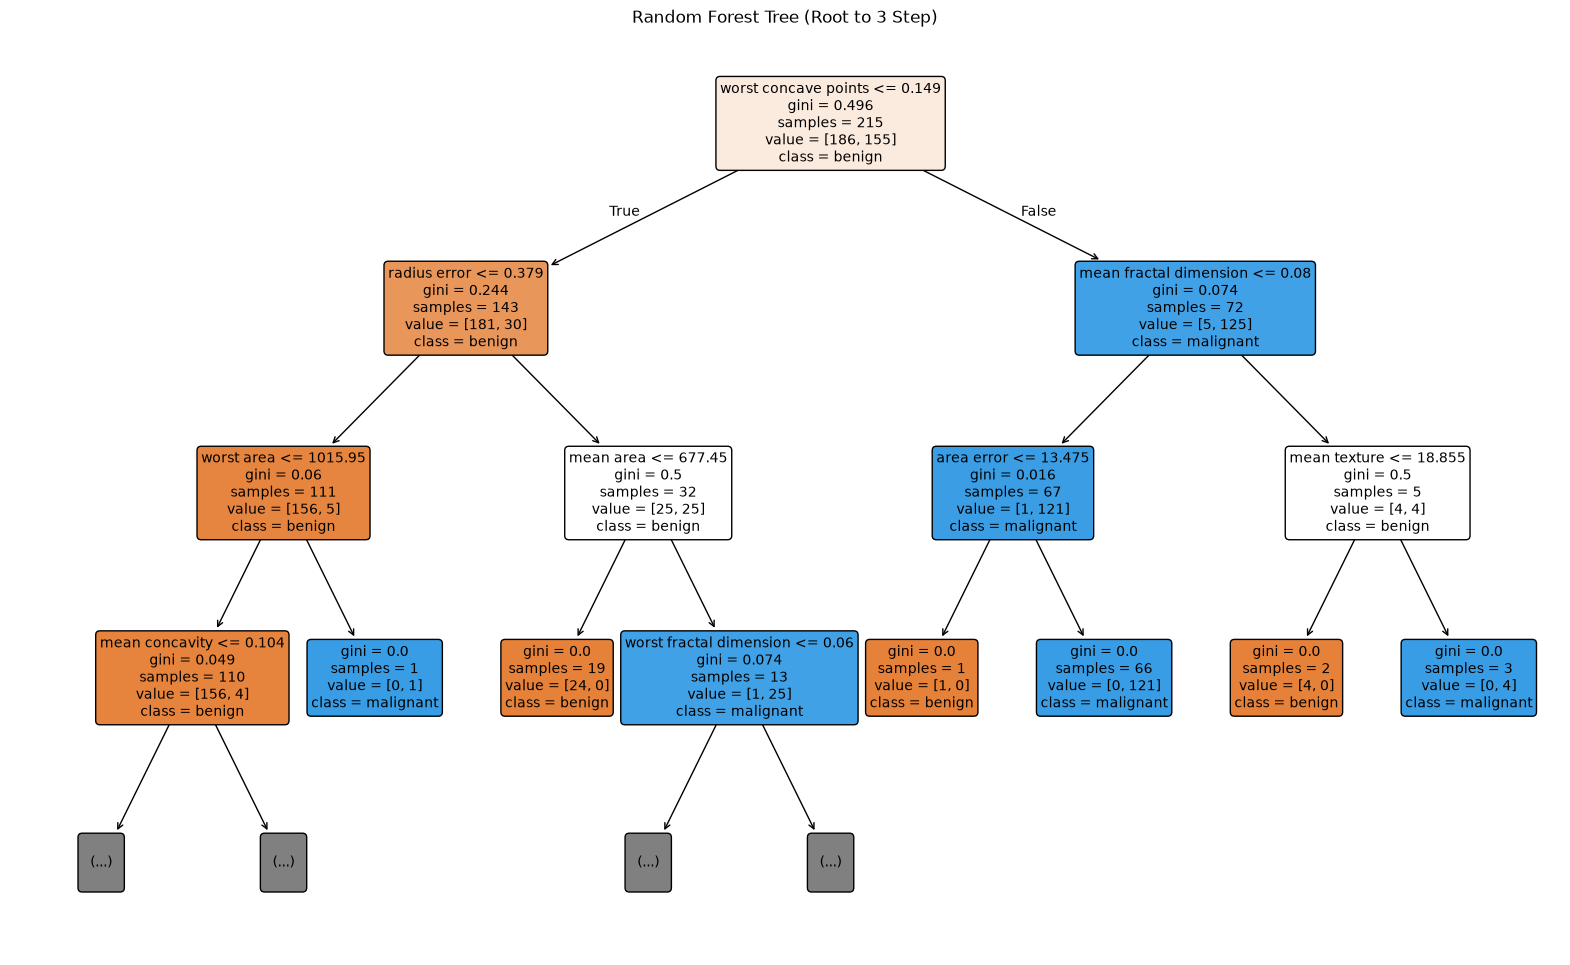

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# selected_template이 forest일 때, 그 안의 나무 하나 꺼내기
one_tree = selected_template.estimators_[0]   # 300개 중 0번째 나무

fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(
    one_tree,
    max_depth=3,                       # 위에서 3단계만! (핵심)
    feature_names=X.columns,           # 특성 이름 표시
    class_names=["benign", "malignant"],
    filled=True,                       # 클래스별 색칠
    rounded=True,
    fontsize=10,
    ax=ax,
)
plt.title("Random Forest Tree (Root to 3 Step)")
plt.show()

## 필수 2. OOB와 두 가지 특성 중요도 해석하기

### 문제 2-1: 내부 점검과 held-out 설명을 분리하기
- Random Forest가 어떤 정보를 사용했고 내부 표본에서 어느 정도 안정적인지 확인해야 합니다.
- `oob_score=True`인 Forest를 train에 학습하고 OOB accuracy를 확인하세요.
- 별도로 한 번도 학습에 사용하지 않은 validation에서 AP를 계산하고, MDI와 validation AP 기반 permutation importance를 나란히 비교하세요.
- OOB는 각 나무의 bootstrap 표본에 포함되지 않은 train 행을 이용한 내부 점검입니다.
- 현재 scikit-learn 설정의 `oob_score_`는 accuracy이므로 validation AP와 숫자만 직접 비교하거나 같은 지표라고 부르면 안 됩니다.

### 수행해야 할 작업
1. 500개 나무와 `oob_score=True`를 사용하는 Forest를 train에 학습하세요.
2. `oob_score_`를 OOB **accuracy**라는 이름으로 출력하세요.
3. validation 양성 확률로 AP를 계산하세요.
4. `feature_importances_`를 MDI 열로 만드세요.
5. validation에서 특성 하나씩 섞고 AP 감소량을 계산하세요.
6. 두 중요도를 같은 표에 합쳐 permutation AP 감소량으로 정렬하세요.
7. 중요도 합계·행 수·지표 범위를 assertion으로 확인하세요.
8. 상위 특성을 인과적 원인으로 해석하면 안 되는 이유를 작성하세요.

In [15]:
def inspect_oob_and_importance(X_train, y_train, X_valid, y_valid):
    # model 객체 생성
    model = RandomForestClassifier(
        # n_estimators: Int = 100,
        n_estimators=500,
        # criterion: Literal['gini', 'entropy', 'log_loss'] = "gini",
        # max_depth: Int | None = None,
        # min_samples_split: float = 2,
        # min_samples_leaf: float = 1,
        # min_weight_fraction_leaf: Float = 0,
        # max_features: float | Literal['sqrt', 'log2'] = "sqrt",
        max_features="sqrt",
        # max_leaf_nodes: Int | None = None,
        # min_impurity_decrease: Float = 0,
        # bootstrap: bool = True,
        # oob_score: bool = False,
        oob_score=True,
        # n_jobs: Int | None = None,
        # random_state: Int | RandomState | None = None,
        random_state=SEED,
        # verbose: Int = 0,
        # warm_start: bool = False,
        # class_weight: Mapping | Sequence[Mapping] | Literal['balanced', 'balanced_subsample'] | None = None,
        class_weight="balanced",
        # ccp_alpha: float = 0,
        # max_samples: float | None = None
    )
    # model 학습
    model.fit(X_train, y_train)
    # oob_score_는 나무별 점수의 평균이 아니라, 각 train 행마다 "그 행을 안 본 나무들"의 투표로 예측을 만들고, 예측 전체를 마지막에 한 번 채점한 accuracy
    oob_accuracy = model.oob_score_
    validation_proba = model.predict_proba(X_valid)[:, 1]
    validation_ap = average_precision_score(y_valid, validation_proba)
    metrics = {
        "OOB_accuracy": oob_accuracy,
        "validation_AP": validation_ap,
    }
    # MDI (Mean Decrease in Impurity)
    # 어떤 특성이 나무에서 분기에 쓰일 때마다, 그 분기가 줄인 불순도를 기록
    # 나무 전체에서 그 특성이 줄인 불순도를 다 더하고 평균
    # -> feature_importances_
    mdi = model.feature_importances_
    # Permutaion Importacne
    # 특성 하나를 골라서, 그 열의 값들을 무작위로 뒤섞음
    # 망가진 데이터로 다시 AP를 측성하여 원래 AP와 비교
    # 모든 특성 각각에 대해 반복 (원래 AP − 섞은 AP) 기록
    perm = permutation_importance(
        # estimator: Any,
        model,
        # X: MatrixLike,
        # y: MatrixLike | ArrayLike | None,
        X_valid, y_valid,
        # scoring: ArrayLike | tuple | ((...) -> Any) | Mapping | None = None,
        scoring="average_precision",
        # n_repeats: Int = 5,
        n_repeats=10,
        # n_jobs: int | None = None,
        # random_state: Int | RandomState | None = None,
        random_state=SEED,
        # sample_weight: ArrayLike | None = None,
        # max_samples: float = 1
    )
    perm_importance = perm.importances_mean
    # 표로 반환하기
    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "MDI": mdi,
        "perm_AP_drop": perm.importances_mean,
    })
    importance_df = importance_df.sort_values(by="perm_AP_drop", ascending=False)
    # 검증
    assert len(importance_df) == 30
    assert np.isclose(importance_df["MDI"].sum(), 1.0)
    assert 0.0 <= oob_accuracy <= 1.0
    assert 0.0 <= validation_ap <= 1.0

    return importance_df, metrics

### 확인할 결과
- OOB 결과에는 `OOB_accuracy`라고 명시되어야 합니다.
- validation 결과에는 `validation_AP`라고 명시되어야 합니다.
- 중요도 표는 원본 특성 수와 같은 30행이어야 합니다.
- MDI 합계는 부동소수점 오차 범위에서 1이어야 합니다.
- permutation 값이 작거나 음수여도 오류로 단정하지 마세요.

In [16]:
importance_df, metrics_ap = inspect_oob_and_importance(X_train, y_train, X_valid, y_valid)

print(f"importance_df.head(10): \n{importance_df.head(10)}\n")
print(f"metrics_ap: \n{metrics_ap}\n")

importance_df.head(10): 
                 feature       MDI  perm_AP_drop
27  worst concave points  0.108003      0.006400
7    mean concave points  0.114200      0.003356
23            worst area  0.113668      0.002892
22       worst perimeter  0.126129      0.002762
13            area error  0.038676      0.001689
20          worst radius  0.082757      0.001524
21         worst texture  0.016472      0.001178
3              mean area  0.041497      0.000849
6         mean concavity  0.059748      0.000792
28        worst symmetry  0.017180      0.000698

metrics_ap: 
{'OOB_accuracy': 0.9589442815249267, 'validation_AP': 0.9944343498577266}



MDI의 편향 (cardinality bias)
- MDI는 ①특성이 분기에 뽑히는 횟수 × ②뽑혔을 때 줄인 불순도의 합으로 계산된다.
- 값 종류가 많은(high-cardinality) 연속형·고유 특성은 자를 후보 지점이 많아 분기에 자주 뽑히고, 표본의 잡음까지 가르는 분기를 찾기 쉽다.
- 그 결과 MDI는 high-cardinality 특성을 과대평가하는 편향이 있다. (train 기반이라 과적합도 반영됨)

#### permutation의 한계 (correlated features)
- worst radius(반지름), worst perimeter(둘레), worst area(넓이) — 이 셋은 사실상 같은 정보
- 즉 반지름이 진짜 중요한 정보인데도, "대체재가 있어서" 섞어도 티가 안 나는 현상
- 상관 특성이 있으면 permutation은 그 특성들의 중요도를 과소평가한다.

- 상위 특성(worst concave points)은 이 모델의 예측이 그 특성에 크게 의존한다는 뜻일 뿐, 종양을 악성으로 만드는 인과적 원인이라고 볼 수 없다.
- MDI는 값 종류가 많은 연속형 특성을 과대평가하는 경향이 있어 여러 특성에 중요도가 분산된다.
- permutation은 상관된 다른 특성이 정보를 메꿔줘서 감소량이 작게 나올 수 있다.
- MDI와 permutation의 순위가 서로 다르게 나오듯, 중요도는 측정에 따라 달라지며 현실의 인과가 아니다.

## 심화 1. Random Forest 설정별 안정성 확인하기

### 문제 3-1: 민감도 분석과 최종 모델 선택 분리하기
- 나무 수와 각 분할에서 고려하는 특성 수가 Random Forest의 CV 결과에 어떤 차이를 만드는지 확인하세요.
- train과 validation을 합친 개발 데이터에서 같은 5-fold Stratified CV와 AP를 사용해 세 설정을 비교합니다. - 평균만 보고 아주 작은 차이를 확정하지 않도록 fold 표준편차도 함께 출력하세요.
- 이 비교는 Random Forest의 동작을 관찰하는 심화 분석입니다.
- 문제 1의 선택 결정을 다시 여는 단계가 아닙니다.
- 최종 test에는 CV 표의 1위 Random Forest를 자동으로 넣지 말고 문제 1의 `selected_template`을 복제하여 사용하세요.

### 수행해야 할 작업
1. train과 validation을 합쳐 `X_dev, y_dev`를 만드세요.
2. `StratifiedKFold(5, shuffle=True, random_state=SEED)`를 사용하세요.
3. `(100, "sqrt")`, `(300, "sqrt")`, `(300, 0.7)`을 비교하세요.
4. 각 설정의 fold AP 평균과 표본 표준편차를 출력하세요.
5. CV 결과는 민감도 표로만 해석하세요.
6. 문제 1의 `selected_template`을 clone하여 개발 데이터 전체에 학습하세요.
7. test AP·F1을 한 번 계산하고 선택 모델 이름과 함께 출력하세요.
8. 최종 모델 class가 선택 template과 같은지 assertion으로 확인하세요.

In [19]:
def compare_forest_settings(X_dev, y_dev, configs, cv):
    """Random Forest 설정별 CV AP 평균과 표준편차를 반환합니다."""
    # 모든 설정은 동일한 cv 객체와 AP를 사용해야 평균 차이를 설정 효과로 비교할 수 있습니다.
    # 이 표는 RF 민감도 분석이며 문제 1에서 선택한 최종 모델 family를 바꾸지 않습니다.
    rows = []

    for n_estimators, max_features in configs:
        # TODO 1: 설정별 Random Forest를 만드세요.
        model = RandomForestClassifier(
            # n_estimators: Int = 100,
            n_estimators = n_estimators,
            # *,
            # criterion: Literal['gini', 'entropy', 'log_loss'] = "gini",
            # max_depth: Int | None = None,
            # min_samples_split: float = 2,
            # min_samples_leaf: float = 1,
            # min_weight_fraction_leaf: Float = 0,
            # max_features: float | Literal['sqrt', 'log2'] = "sqrt",
            max_features = max_features,
            # max_leaf_nodes: Int | None = None,
            # min_impurity_decrease: Float = 0,
            # bootstrap: bool = True,
            # oob_score: bool = False,
            # n_jobs: Int | None = None,
            # random_state: Int | RandomState | None = None,
            random_state = SEED,
            # verbose: Int = 0,
            # warm_start: bool = False,
            # class_weight: Mapping | Sequence[Mapping] | Literal['balanced', 'balanced_subsample'] | None = None,
            class_weight = "balanced",
            # ccp_alpha: float = 0,
            # max_samples: float | None = None
        )
        # TODO 2: 같은 CV와 AP로 fold 점수를 계산하세요.
        # cross_val_score는 "모델 하나 + 데이터 + 자르는 규칙"을 받아서, fold마다 학습·평가를 반복하고 점수 배열을 돌려주는 함수
        # cv로 자르고, 매 fold clone으로 깨끗한 모델을 만들고, scoring 문자열에 맞춰 predict_proba냐 predict냐까지 알아서 골라 채점한 뒤, fold 점수 배열을 돌려준다.
        # 그 배열에서 .mean()과 .std(ddof=1)을 뽑는 게 우리가 원하는 "평균 ± 흔들림"이다.
        fold_ap = cross_val_score(
            # estimator: BaseEstimator,
            model,
            # X: MatrixLike,
            # y: MatrixLike | ArrayLike | None = None,
            X_dev, y_dev,
            # *,
            # groups: ArrayLike | None = None,
            # scoring: str | ((...) -> Any) | None = None,
            scoring = "average_precision",
            # cv: int | BaseCrossValidator | Iterable | None = None,
            cv = cv,
            # n_jobs: Int | None = None,
            # verbose: Int = 0,
            # fit_params: dict | None = None,
            # pre_dispatch: Int | str = "2*n_jobs",
            # error_score: Float | str = np.nan
        )
        # 
        rows.append({
            "n_estimators": n_estimators,
            "max_features": max_features,
            "mean_AP": fold_ap.mean(),
            # Delta Degrees of Freedom (자유도 조정)
            # 분산 = ∑(xi​−xˉ)2 / N−ddof​
            "std_AP": fold_ap.std(ddof=1)
        })

    # fold 표준편차는 평균의 표준오차가 아니므로 이름과 해석을 구분하세요.
    # TODO 3: 평균 AP 내림차순 표를 반환하세요.
    table = (
        pd.DataFrame(rows)
        .sort_values("mean_AP", ascending=False)
        .reset_index(drop=True)
    )

    return table

In [22]:
X_dev = pd.concat([X_train, X_valid])
y_dev = pd.concat([y_train, y_valid])
print(f"X_dev: {X_dev.shape}") # (455, 30)
print(f"y_dev positive rate: {y_dev.mean():.2f}") # 0.37

# cv 객체의 본체는 .split(X, y) → 인덱스 쌍 5개를 내주는 규칙서
configs =[(100, "sqrt"), (300, "sqrt"), (300, 0.7)]

# (n_splits: Int = 5, *, shuffle: bool = False, random_state: Int | RandomState | None = None)
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

cv_table = compare_forest_settings(X_dev, y_dev, configs, cv)
print(cv_table.to_markdown())

X_dev: (455, 30)
y_dev positive rate: 0.37
|    |   n_estimators | max_features   |   mean_AP |    std_AP |
|---:|---------------:|:---------------|----------:|----------:|
|  0 |            100 | sqrt           |  0.987661 | 0.0125693 |
|  1 |            300 | sqrt           |  0.986935 | 0.0132532 |
|  2 |            300 | 0.7            |  0.984979 | 0.0127461 |


### 확인할 결과
- CV 표에는 설정 세 개가 각각 한 행씩 있어야 합니다.
- `std_AP`는 fold 간 AP 변동을 나타내며 0 이상이어야 합니다.
- 가장 높은 평균과 다른 설정의 차이가 표준편차보다 작다면 우열을 강하게 단정하지 마세요.
- 최종 `selected_name`은 문제 1에서 정한 값과 같아야 합니다.
- test는 어떤 설정이나 임계값을 다시 고르는 데 사용하지 마세요.

In [21]:
final_model = clone(selected_template)
final_model.fit(X_dev, y_dev)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

test_ap = average_precision_score(y_test, test_proba)
test_f1 = f1_score(y_test, test_pred)

print(f"Test AP: {test_ap}")
print(f"Test F1: {test_f1}")


Test AP: 0.9922370357586304
Test F1: 0.9411764705882353


### 제출해야 할 결과

```
n_estimators | max_features | mean_AP | std_AP

[민감도 및 최종 test 보고]
- 평균 AP가 가장 높은 RF 설정:
- 설정 간 평균 차이:
- fold 표준편차:
- 차이를 과도하게 해석하면 안 되는 이유:
- 문제 1 선택 모델:
- 최종 test AP / F1:
- test를 한 번만 사용한 이유:
```

|    |   n_estimators | max_features   |   mean_AP |    std_AP |
|---:|---------------:|:---------------|----------:|----------:|
|  0 |            100 | sqrt           |  0.987661 | 0.0125693 |
|  1 |            300 | sqrt           |  0.986935 | 0.0132532 |
|  2 |            300 | 0.7            |  0.984979 | 0.0127461 |

```
[민감도 및 최종 test 보고]
- 평균 AP가 가장 높은 RF 설정: n_estimators=100, max_features="sqrt"
- 설정 간 평균 차이: 1위와 2위와 평균 차이는 0.000726, 1위와 3위의 평균 차이는 0.002682
- fold 표준편차: 0.0125693, 0.0132532, 0.0127461
- 차이를 과도하게 해석하면 안 되는 이유: 설정 간 평균 차이가 각 설저으이 fold 표준편차보다 훨씬 작다. 즉 이 격차는 설정 효과라기보다 fold 분할에 따른 변동 범위 안에 있으므로, 특정 설정이 더 우수하다고 단정할 수 없다.
- 문제 1 선택 모델: RandomForest
- 최종 test AP / F1: Test AP: 0.9922370357586304, Test F1: 0.9411764705882353
- test를 한 번만 사용한 이유: 실제 성능평가를 위해 학습과 검증에 사용되지 않은 데이터로 평가하여, 모델의 성능을 평가한다.
```